tensor([[0.9165]], requires_grad=True)


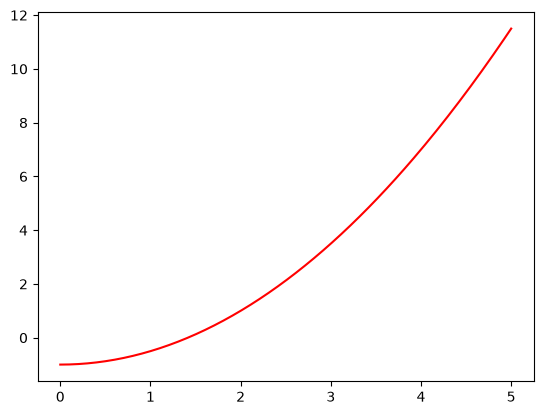

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

x=torch.tensor(np.linspace(0,5,200))
y=-1+0.5*x**2

a=torch.rand(size=(1,1), requires_grad=True)
b=torch.rand(size=(1,1), requires_grad=True)
lr=1e-4
plt.plot(x,y,'-r',label='Datos originales')

print(a)

In [2]:
y_est=a+b*x**2
error=torch.mean((y_est-y)**2)
print('error actual: ',error)
a.grad=None
b.grad=None

error.backward()
print(a.grad, b.grad)
a=a-lr*a.grad
b=b-lr*b.grad
y_est=a+b*x**2
error=torch.mean((y_est-y)**2)
print('Nuevo error: ', error)


error actual:  tensor(6.2673, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor([[4.9124]]) tensor([[48.2948]])
Nuevo error:  tensor(6.0346, dtype=torch.float64, grad_fn=<MeanBackward0>)


0 43.50054700824232
5000 0.3652386278643299
10000 0.15032172879688446
15000 0.06186838842183915
20000 0.025463471124827254
25000 0.010480181275344239
30000 0.004313431166319968
35000 0.0017753838317078462
40000 0.0007307424114021508
45000 0.0003007769556731846


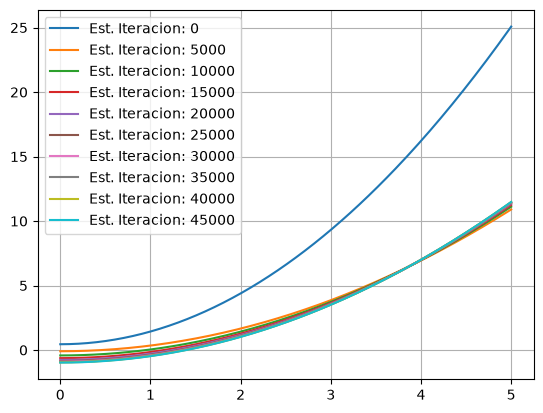

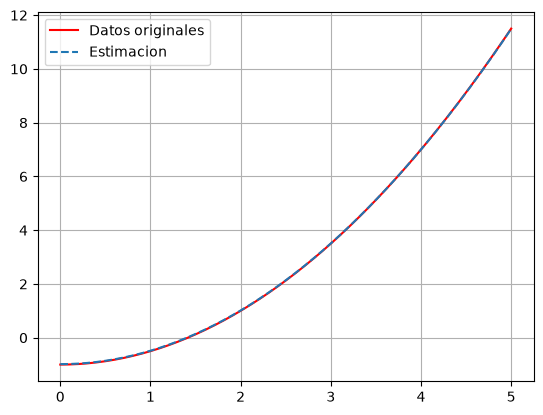

In [3]:
a=torch.rand(size=(1,1), requires_grad=True)
b=torch.rand(size=(1,1), requires_grad=True)

for i in range(50000):
  loss=((y-(a+b*x**2))**2).mean()
  if(i%5000==0):
    print(i,loss.item())
    with torch.no_grad():
      y_est=(a+b*x**2).numpy().ravel()
      plt.plot(x.numpy(),y_est,'-',label='Est. Iteracion: '+str(i))

  a.grad=None
  b.grad=None
  loss.backward()
  with torch.no_grad():
    a-=lr*a.grad
    b-=lr*b.grad
plt.grid()
plt.legend()

plt.figure()
plt.plot(x,y,'-r',label='Datos originales')
with torch.no_grad():
  y_est=(a+b*x**2).numpy().ravel()
  plt.plot(x.numpy(),y_est,'--',label='Estimacion')
plt.grid()
plt.legend()